# Stage 3 — Model Development & Tracking

In [1]:
import sys
import importlib

sys.path.insert(0, ".")

import data_prep as dp
import config as cfg

importlib.reload(dp)
importlib.reload(cfg)

print("data_prep loaded:", hasattr(dp, "prepare"))
print("config loaded:", cfg.DATA_PATH)

data_prep loaded: True
config loaded: diabetic_data.csv


In [2]:
import config as cfg

print("Config loaded from:")
print(cfg.__file__)

print("\nDATA_PATH:", cfg.DATA_PATH)
print("RANDOM_STATE:", cfg.RANDOM_STATE)

Config loaded from:
c:\Users\mithu\Music\MLProjects\hospital-readmission-prediction\config.py

DATA_PATH: diabetic_data.csv
RANDOM_STATE: 42


In [3]:
X, y, X_train, X_val, X_test, y_train, y_val, y_test = dp.prepare(
    cfg.DATA_PATH
)

print("========================================")
print("Stage 3 Data Preparation Validation")
print("========================================")

print("Full dataset:", X.shape)
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nPositive rates:")
print("Full:", round(y.mean() * 100, 2), "%")
print("Train:", round(y_train.mean() * 100, 2), "%")
print("Validation:", round(y_val.mean() * 100, 2), "%")
print("Test:", round(y_test.mean() * 100, 2), "%")

c:\Users\mithu\Music\MLProjects\hospital-readmission-prediction\data_prep.py:75: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path, na_values=["?"])


Stage 3 Data Preparation Validation
Full dataset: (69973, 54)
Train: (48981, 54)
Validation: (10496, 54)
Test: (10496, 54)

Target distribution:
target
0    63696
1     6277
Name: count, dtype: int64

Positive rates:
Full: 8.97 %
Train: 8.97 %
Validation: 8.97 %
Test: 8.97 %


In [4]:
print("dp exists:", "dp" in globals())
print("cfg exists:", "cfg" in globals())
print("X_train exists:", "X_train" in globals())
print("preprocessor exists:", "preprocessor" in globals())

dp exists: True
cfg exists: True
X_train exists: True
preprocessor exists: False


In [5]:
print("baseline_model exists:", "baseline_model" in globals())
print("xgb_model exists:", "xgb_model" in globals())

baseline_model exists: False
xgb_model exists: False


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

baseline_model = Pipeline([
    ("preprocessor", dp.build_preprocessor(X_train)),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=cfg.RANDOM_STATE
        )
    )
])

print("========================================")
print("Logistic Regression Baseline")
print("========================================")

print("Pipeline created successfully")
print("Steps:", list(baseline_model.named_steps.keys()))

Logistic Regression Baseline
Pipeline created successfully
Steps: ['preprocessor', 'classifier']


In [7]:
numeric_features, categorical_features = dp.get_feature_lists(X_train)

print("========================================")
print("Feature Coverage Validation")
print("========================================")

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total features:", len(numeric_features) + len(categorical_features))

print("\nNumeric features:")
print(numeric_features)

print("\nExcluded raw features:")
excluded_raw = [
    "age",
    "diag_1",
    "diag_2",
    "diag_3",
    "medical_specialty"
]

print([
    col for col in excluded_raw
    if col in X_train.columns
])

print("\nTarget/ID leakage check:")
leakage_columns = [
    "target",
    "encounter_id",
    "patient_nbr",
    "readmitted"
]

print([
    col for col in leakage_columns
    if col in numeric_features + categorical_features
])

Feature Coverage Validation
Numeric features: 11
Categorical features: 35
Total features: 46

Numeric features:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age_midpoint', 'total_prior_visits', 'medication_change_count']

Excluded raw features:
['age', 'diag_1', 'diag_2', 'diag_3', 'medical_specialty']

Target/ID leakage check:
[]


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

baseline_preprocessor = dp.build_preprocessor(X_train)

baseline_model = Pipeline([
    ("preprocessor", baseline_preprocessor),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=cfg.RANDOM_STATE
        )
    )
])

print("========================================")
print("Logistic Regression Baseline")
print("========================================")

print("Pipeline created successfully")
print("Steps:", list(baseline_model.named_steps.keys()))

Logistic Regression Baseline
Pipeline created successfully
Steps: ['preprocessor', 'classifier']


In [9]:
print("========================================")
print("Training Logistic Regression Baseline")
print("========================================")

baseline_model.fit(X_train, y_train)

print("Baseline model training completed successfully.")

Training Logistic Regression Baseline
Baseline model training completed successfully.


In [10]:
print("========================================")
print("Generating Validation Predictions")
print("========================================")

y_val_proba = baseline_model.predict_proba(X_val)[:, 1]
y_val_pred = baseline_model.predict(X_val)

print("Validation predictions generated successfully.")

print("\nPrediction shapes:")
print("Probability predictions:", y_val_proba.shape)
print("Class predictions:", y_val_pred.shape)

print("\nFirst 10 predicted probabilities:")
print(y_val_proba[:10])

print("\nFirst 10 predicted classes:")
print(y_val_pred[:10])

Generating Validation Predictions
Validation predictions generated successfully.

Prediction shapes:
Probability predictions: (10496,)
Class predictions: (10496,)

First 10 predicted probabilities:
[0.61149479 0.4767683  0.69602988 0.42645383 0.45507843 0.61223768
 0.60469274 0.34271011 0.38784903 0.41060749]

First 10 predicted classes:
[1 0 1 0 0 1 1 0 0 0]


In [11]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score
)

print("========================================")
print("Logistic Regression - Validation Metrics")
print("========================================")

baseline_roc_auc = roc_auc_score(y_val, y_val_proba)
baseline_pr_auc = average_precision_score(y_val, y_val_proba)
baseline_recall = recall_score(y_val, y_val_pred)
baseline_precision = precision_score(y_val, y_val_pred)
baseline_f1 = f1_score(y_val, y_val_pred)
baseline_accuracy = accuracy_score(y_val, y_val_pred)

print(f"ROC-AUC  : {baseline_roc_auc:.4f}")
print(f"PR-AUC   : {baseline_pr_auc:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")
print(f"Accuracy : {baseline_accuracy:.4f}")

Logistic Regression - Validation Metrics
ROC-AUC  : 0.6413
PR-AUC   : 0.1703
Recall   : 0.5287
Precision: 0.1362
F1 Score : 0.2166
Accuracy : 0.6567


In [12]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [13]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("========================================")
print("XGBoost Class Weight")
print("========================================")

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)
print("scale_pos_weight:", round(scale_pos_weight, 4))

XGBoost Class Weight
Negative samples: 44587
Positive samples: 4394
scale_pos_weight: 10.1472


In [14]:
xgb_preprocessor = dp.build_preprocessor(X_train)

xgb_model = Pipeline([
    ("preprocessor", xgb_preprocessor),
    (
        "classifier",
        xgb.XGBClassifier(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            min_child_weight=5,
            reg_lambda=2.0,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            random_state=cfg.RANDOM_STATE,
            eval_metric="logloss",
            n_jobs=-1
        )
    )
])

print("========================================")
print("XGBoost Advanced Pipeline")
print("========================================")

print("Pipeline created successfully")
print("Steps:", list(xgb_model.named_steps.keys()))

XGBoost Advanced Pipeline
Pipeline created successfully
Steps: ['preprocessor', 'classifier']


In [15]:
print("========================================")
print("Training XGBoost Advanced Model")
print("========================================")

xgb_model.fit(X_train, y_train)

print("XGBoost model training completed successfully.")

Training XGBoost Advanced Model
XGBoost model training completed successfully.


In [16]:
print("========================================")
print("Generating XGBoost Validation Predictions")
print("========================================")

xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]
xgb_val_pred = xgb_model.predict(X_val)

print("Validation predictions generated successfully.")

print("\nPrediction shapes:")
print("Probability predictions:", xgb_val_proba.shape)
print("Class predictions:", xgb_val_pred.shape)

print("\nFirst 10 predicted probabilities:")
print(xgb_val_proba[:10])

print("\nFirst 10 predicted classes:")
print(xgb_val_pred[:10])

Generating XGBoost Validation Predictions
Validation predictions generated successfully.

Prediction shapes:
Probability predictions: (10496,)
Class predictions: (10496,)

First 10 predicted probabilities:
[0.6066331  0.46403617 0.5617651  0.4687374  0.39295933 0.5529243
 0.4322376  0.3416788  0.37793976 0.37750623]

First 10 predicted classes:
[1 0 1 0 0 1 0 0 0 0]


In [17]:
print("========================================")
print("XGBoost - Validation Metrics")
print("========================================")

xgb_roc_auc = roc_auc_score(y_val, xgb_val_proba)
xgb_pr_auc = average_precision_score(y_val, xgb_val_proba)
xgb_recall = recall_score(y_val, xgb_val_pred)
xgb_precision = precision_score(y_val, xgb_val_pred)
xgb_f1 = f1_score(y_val, xgb_val_pred)
xgb_accuracy = accuracy_score(y_val, xgb_val_pred)

print(f"ROC-AUC  : {xgb_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_pr_auc:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"Accuracy : {xgb_accuracy:.4f}")

XGBoost - Validation Metrics
ROC-AUC  : 0.6502
PR-AUC   : 0.1814
Recall   : 0.5191
Precision: 0.1413
F1 Score : 0.2221
Accuracy : 0.6737


In [18]:
import pandas as pd 

In [19]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost"
    ],
    "ROC-AUC": [
        baseline_roc_auc,
        xgb_roc_auc
    ],
    "PR-AUC": [
        baseline_pr_auc,
        xgb_pr_auc
    ],
    "Recall": [
        baseline_recall,
        xgb_recall
    ],
    "Precision": [
        baseline_precision,
        xgb_precision
    ],
    "F1": [
        baseline_f1,
        xgb_f1
    ],
    "Accuracy": [
        baseline_accuracy,
        xgb_accuracy
    ]
})

comparison = comparison.set_index("Model")

print("========================================")
print("Model Comparison")
print("========================================")

print(comparison.round(4))

print("\nSelected model based on validation ROC-AUC:")
print(comparison["ROC-AUC"].idxmax())

Model Comparison
                     ROC-AUC  PR-AUC  Recall  Precision      F1  Accuracy
Model                                                                    
Logistic Regression   0.6413  0.1703  0.5287     0.1362  0.2166    0.6567
XGBoost               0.6502  0.1814  0.5191     0.1413  0.2221    0.6737

Selected model based on validation ROC-AUC:
XGBoost


In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, xgb_val_pred)

print("========================================")
print("XGBoost - Validation Confusion Matrix")
print("========================================")

print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print("\nTotal:", tn + fp + fn + tp)

XGBoost - Validation Confusion Matrix
[[6582 2972]
 [ 453  489]]

TN: 6582
FP: 2972
FN: 453
TP: 489

Total: 10496


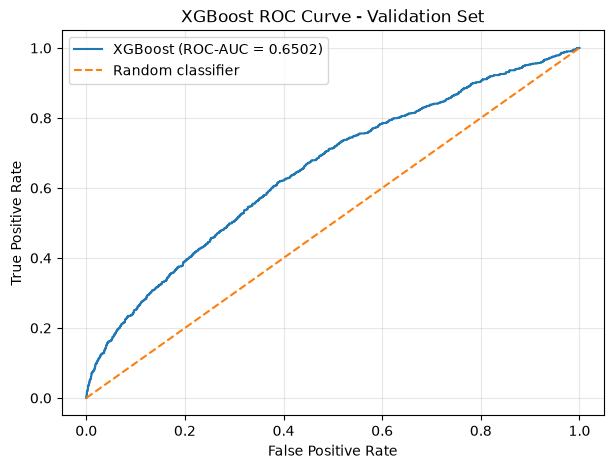

In [21]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_val,
    xgb_val_proba
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (ROC-AUC = {xgb_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve - Validation Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

XGBoost - Validation Confusion Matrix Plot


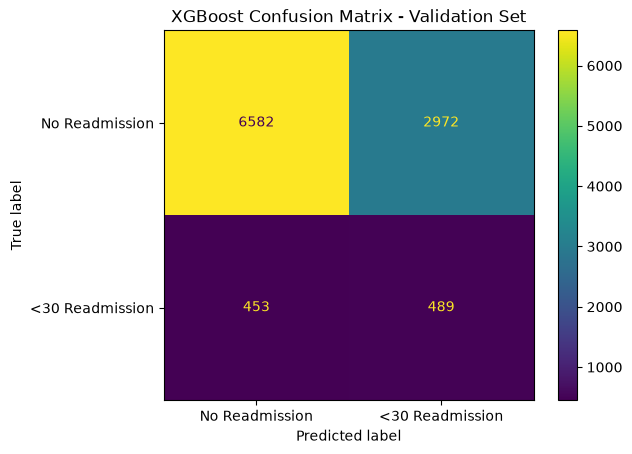

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("========================================")
print("XGBoost - Validation Confusion Matrix Plot")
print("========================================")

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Readmission", "<30 Readmission"]
).plot()

plt.title("XGBoost Confusion Matrix - Validation Set")
plt.show()

In [23]:
print("========================================")
print("Generating XGBoost Test Predictions")
print("========================================")

xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_test_pred = xgb_model.predict(X_test)

print("Test predictions generated successfully.")

print("\nPrediction shapes:")
print("Probability predictions:", xgb_test_proba.shape)
print("Class predictions:", xgb_test_pred.shape)

Generating XGBoost Test Predictions
Test predictions generated successfully.

Prediction shapes:
Probability predictions: (10496,)
Class predictions: (10496,)


In [24]:
print("========================================")
print("XGBoost - Final Test Metrics")
print("========================================")

xgb_test_roc_auc = roc_auc_score(y_test, xgb_test_proba)
xgb_test_pr_auc = average_precision_score(y_test, xgb_test_proba)
xgb_test_recall = recall_score(y_test, xgb_test_pred)
xgb_test_precision = precision_score(y_test, xgb_test_pred)
xgb_test_f1 = f1_score(y_test, xgb_test_pred)
xgb_test_accuracy = accuracy_score(y_test, xgb_test_pred)

print(f"ROC-AUC  : {xgb_test_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_test_pr_auc:.4f}")
print(f"Recall   : {xgb_test_recall:.4f}")
print(f"Precision: {xgb_test_precision:.4f}")
print(f"F1 Score : {xgb_test_f1:.4f}")
print(f"Accuracy : {xgb_test_accuracy:.4f}")

XGBoost - Final Test Metrics
ROC-AUC  : 0.6557
PR-AUC   : 0.1814
Recall   : 0.5197
Precision: 0.1418
F1 Score : 0.2228
Accuracy : 0.6749


In [25]:
test_cm = confusion_matrix(y_test, xgb_test_pred)

tn_test, fp_test, fn_test, tp_test = test_cm.ravel()

print("========================================")
print("XGBoost - Final Test Confusion Matrix")
print("========================================")

print(test_cm)

print("\nTN:", tn_test)
print("FP:", fp_test)
print("FN:", fn_test)
print("TP:", tp_test)

print("\nTotal:", tn_test + fp_test + fn_test + tp_test)

XGBoost - Final Test Confusion Matrix
[[6595 2960]
 [ 452  489]]

TN: 6595
FP: 2960
FN: 452
TP: 489

Total: 10496


In [26]:
import mlflow

print("MLflow version:", mlflow.__version__)

MLflow version: 3.16.0


In [27]:
from pathlib import Path

print("========================================")
print("MLflow Project Files Check")
print("========================================")

project_root = Path.cwd()

print("Current project:")
print(project_root)

print("\nMLflow-related files:")
mlflow_files = [
    p for p in project_root.iterdir()
    if "mlflow" in p.name.lower()
]

if mlflow_files:
    for p in mlflow_files:
        print("-", p.name)
else:
    print("No MLflow-related files found.")

MLflow Project Files Check
Current project:
c:\Users\mithu\Music\MLProjects\hospital-readmission-prediction

MLflow-related files:
No MLflow-related files found.


In [28]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")

print("========================================")
print("MLflow Configuration")
print("========================================")

print("MLflow version:", mlflow.__version__)
print("Tracking URI:", mlflow.get_tracking_uri())

MLflow Configuration
MLflow version: 3.16.0
Tracking URI: sqlite:///mlflow.db


In [29]:
EXPERIMENT_NAME = "hospital_readmission_prediction"

mlflow.set_experiment(EXPERIMENT_NAME)

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

print("========================================")
print("MLflow Experiment")
print("========================================")

print("Experiment name:", experiment.name)
print("Experiment ID:", experiment.experiment_id)
print("Artifact location:", experiment.artifact_location)

2026/09/07 13:30:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/07 13:30:37 INFO mlflow.store.db.utils: Updating database tables
2026/09/07 13:30:39 INFO mlflow.tracking.fluent: Experiment with name 'hospital_readmission_prediction' does not exist. Creating a new experiment.


MLflow Experiment
Experiment name: hospital_readmission_prediction
Experiment ID: 1
Artifact location: file:///c:/Users/mithu/Music/MLProjects/hospital-readmission-prediction/mlruns/1


In [30]:
with mlflow.start_run(run_name="logreg_baseline_v1"):

    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("max_iter", 2000)
    mlflow.log_param("random_state", cfg.RANDOM_STATE)

    mlflow.log_metric("val_roc_auc", baseline_roc_auc)
    mlflow.log_metric("val_pr_auc", baseline_pr_auc)
    mlflow.log_metric("val_recall", baseline_recall)
    mlflow.log_metric("val_precision", baseline_precision)
    mlflow.log_metric("val_f1", baseline_f1)
    mlflow.log_metric("val_accuracy", baseline_accuracy)

    print("========================================")
    print("MLflow - Logistic Regression Run")
    print("========================================")

    print("Run ID:", mlflow.active_run().info.run_id)
    print("Run logged successfully.")

MLflow - Logistic Regression Run
Run ID: 67223a5e43c146bfa723b041d1c15942
Run logged successfully.


In [31]:
with mlflow.start_run(run_name="xgboost_advanced_v1"):

    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("n_estimators", 400)
    mlflow.log_param("max_depth", 4)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("min_child_weight", 5)
    mlflow.log_param("reg_lambda", 2.0)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("scale_pos_weight", scale_pos_weight)
    mlflow.log_param("random_state", cfg.RANDOM_STATE)

    mlflow.log_metric("val_roc_auc", xgb_roc_auc)
    mlflow.log_metric("val_pr_auc", xgb_pr_auc)
    mlflow.log_metric("val_recall", xgb_recall)
    mlflow.log_metric("val_precision", xgb_precision)
    mlflow.log_metric("val_f1", xgb_f1)
    mlflow.log_metric("val_accuracy", xgb_accuracy)

    print("========================================")
    print("MLflow - XGBoost Run")
    print("========================================")

    print("Run ID:", mlflow.active_run().info.run_id)
    print("Run logged successfully.")

MLflow - XGBoost Run
Run ID: b604e7a25cee473b89704955401b4bc4
Run logged successfully.


In [32]:
runs = mlflow.search_runs(
    experiment_names=["hospital_readmission_prediction"]
)

print("========================================")
print("MLflow Runs")
print("========================================")

print(
    runs[
        [
            "run_id",
            "status",
            "params.model",
            "metrics.val_roc_auc",
            "metrics.val_pr_auc",
            "metrics.val_recall",
            "metrics.val_precision",
            "metrics.val_f1",
            "metrics.val_accuracy"
        ]
    ].to_string(index=False)
)

MLflow Runs
                          run_id   status       params.model  metrics.val_roc_auc  metrics.val_pr_auc  metrics.val_recall  metrics.val_precision  metrics.val_f1  metrics.val_accuracy
b604e7a25cee473b89704955401b4bc4 FINISHED            XGBoost             0.650240            0.181402            0.519108               0.141289        0.222121              0.673685
67223a5e43c146bfa723b041d1c15942 FINISHED LogisticRegression             0.641318            0.170348            0.528662               0.136177        0.216569              0.656726


In [34]:
with mlflow.start_run(run_name="xgboost_selected_v1") as run:

    # Log model parameters
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("n_estimators", 400)
    mlflow.log_param("max_depth", 4)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("min_child_weight", 5)
    mlflow.log_param("reg_lambda", 2.0)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("scale_pos_weight", scale_pos_weight)
    mlflow.log_param("random_state", cfg.RANDOM_STATE)

    # Log validation metrics
    mlflow.log_metric("val_roc_auc", xgb_roc_auc)
    mlflow.log_metric("val_pr_auc", xgb_pr_auc)
    mlflow.log_metric("val_recall", xgb_recall)
    mlflow.log_metric("val_precision", xgb_precision)
    mlflow.log_metric("val_f1", xgb_f1)
    mlflow.log_metric("val_accuracy", xgb_accuracy)

    # Log the complete trained Pipeline
    mlflow.sklearn.log_model(
        sk_model=xgb_model,
        name="model",
        skops_trusted_types=[
            "numpy.dtype",
            "xgboost.core.Booster",
            "xgboost.sklearn.XGBClassifier"
        ]
    )

    print("========================================")
    print("MLflow - Selected XGBoost Model")
    print("========================================")
    print("Run ID:", run.info.run_id)
    print("Model artifact logged successfully.")

MLflow - Selected XGBoost Model
Run ID: 128b578c76aa401b8bf1685bc5f73eb8
Model artifact logged successfully.


In [37]:
print("========================================")
print("MLflow Logged Model")
print("========================================")

for model_id in logged_models:
    print("Logged Model ID:", model_id)

MLflow Logged Model
Logged Model ID: artifact_location
Logged Model ID: creation_timestamp
Logged Model ID: experiment_id
Logged Model ID: last_updated_timestamp
Logged Model ID: metrics
Logged Model ID: model_id
Logged Model ID: model_type
Logged Model ID: name
Logged Model ID: params
Logged Model ID: source_run_id
Logged Model ID: status
Logged Model ID: status_message
Logged Model ID: tags


In [38]:
print("========================================")
print("Logged Model Response Type")
print("========================================")

print("Type:", type(logged_models))
print("\nKeys / contents:")

if isinstance(logged_models, dict):
    for key, value in logged_models.items():
        print(f"{key}: {value}")
else:
    print(logged_models)

Logged Model Response Type
Type: <class 'pandas.DataFrame'>

Keys / contents:
                                   artifact_location  creation_timestamp  \
0  file:///c:/Users/mithu/Music/MLProjects/hospit...       1788768844260   

  experiment_id  last_updated_timestamp  \
0             1           1788768860106   

                                             metrics  \
0  [<Metric: dataset_digest=None, dataset_name=No...   

                             model_id model_type   name  \
0  m-5af1694eb07b48be97b86db63162ad73       None  model   

                                              params  \
0  {'colsample_bytree': '0.8', 'learning_rate': '...   

                      source_run_id status status_message  \
0  128b578c76aa401b8bf1685bc5f73eb8  READY           None   

                                                tags  
0  {'mlflow.source.name': 'model_development_and_...  


In [39]:
logged_model_id = logged_models.iloc[0]["model_id"]

print("========================================")
print("Selected MLflow Logged Model")
print("========================================")
print("Model ID:", logged_model_id)
print("Status:", logged_models.iloc[0]["status"])
print("Source Run ID:", logged_models.iloc[0]["source_run_id"])

Selected MLflow Logged Model
Model ID: m-5af1694eb07b48be97b86db63162ad73
Status: READY
Source Run ID: 128b578c76aa401b8bf1685bc5f73eb8


In [40]:
REGISTERED_MODEL_NAME = "hospital_readmission_xgboost"

registered_model = mlflow.register_model(
    model_uri=f"models:/{logged_model_id}",
    name=REGISTERED_MODEL_NAME
)

print("========================================")
print("MLflow Model Registration")
print("========================================")
print("Registered model:", registered_model.name)
print("Model version:", registered_model.version)
print("Status:", registered_model.status)

MLflow Model Registration
Registered model: hospital_readmission_xgboost
Model version: 1
Status: READY


Successfully registered model 'hospital_readmission_xgboost'.
Created version '1' of model 'hospital_readmission_xgboost'.


In [41]:
client = mlflow.tracking.MlflowClient()

print("========================================")
print("MLflow Registered Model")
print("========================================")

model_versions = client.search_model_versions(
    f"name='{REGISTERED_MODEL_NAME}'"
)

for version in model_versions:
    print("Model name:", version.name)
    print("Version:", version.version)
    print("Status:", version.status)
    print("Run ID:", version.run_id)
    print("Source:", version.source)
    print("----------------------------------------")

MLflow Registered Model
Model name: hospital_readmission_xgboost
Version: 1
Status: READY
Run ID: 128b578c76aa401b8bf1685bc5f73eb8
Source: models:/m-5af1694eb07b48be97b86db63162ad73
----------------------------------------


In [42]:
id="set_production_alias"
client = mlflow.tracking.MlflowClient()

REGISTERED_MODEL_NAME = "hospital_readmission_xgboost"
PRODUCTION_ALIAS = "production"
MODEL_VERSION = "1"

client.set_registered_model_alias(
    name=REGISTERED_MODEL_NAME,
    alias=PRODUCTION_ALIAS,
    version=MODEL_VERSION
)

print("========================================")
print("MLflow Production Alias")
print("========================================")
print("Registered model:", REGISTERED_MODEL_NAME)
print("Production alias:", PRODUCTION_ALIAS)
print("Assigned version:", MODEL_VERSION)
print("Alias assigned successfully.")

MLflow Production Alias
Registered model: hospital_readmission_xgboost
Production alias: production
Assigned version: 1
Alias assigned successfully.


In [43]:
client = mlflow.tracking.MlflowClient()

production_version = client.get_model_version_by_alias(
    name="hospital_readmission_xgboost",
    alias="production"
)

print("========================================")
print("MLflow Production Alias Verification")
print("========================================")
print("Registered model:", production_version.name)
print("Alias: production")
print("Version:", production_version.version)
print("Status:", production_version.status)
print("Run ID:", production_version.run_id)
print("Source:", production_version.source)

MLflow Production Alias Verification
Registered model: hospital_readmission_xgboost
Alias: production
Version: 1
Status: READY
Run ID: 128b578c76aa401b8bf1685bc5f73eb8
Source: models:/m-5af1694eb07b48be97b86db63162ad73


In [44]:
print("========================================")
print("XGBoost Pipeline Input Features")
print("========================================")

print("Number of features:", len(xgb_model.feature_names_in_))

for i, feature in enumerate(xgb_model.feature_names_in_, start=1):
    print(f"{i:02d}. {feature}")

XGBoost Pipeline Input Features
Number of features: 54
01. encounter_id
02. patient_nbr
03. race
04. gender
05. age
06. admission_type_id
07. discharge_disposition_id
08. admission_source_id
09. time_in_hospital
10. payer_code
11. medical_specialty
12. num_lab_procedures
13. num_procedures
14. num_medications
15. number_outpatient
16. number_emergency
17. number_inpatient
18. diag_1
19. diag_2
20. diag_3
21. number_diagnoses
22. max_glu_serum
23. A1Cresult
24. metformin
25. repaglinide
26. nateglinide
27. chlorpropamide
28. glimepiride
29. acetohexamide
30. glipizide
31. glyburide
32. tolbutamide
33. pioglitazone
34. rosiglitazone
35. acarbose
36. miglitol
37. troglitazone
38. tolazamide
39. insulin
40. glyburide-metformin
41. glipizide-metformin
42. glimepiride-pioglitazone
43. metformin-rosiglitazone
44. metformin-pioglitazone
45. change
46. diabetesMed
47. readmitted
48. diag_1_category
49. diag_2_category
50. diag_3_category
51. age_midpoint
52. total_prior_visits
53. medication_ch

In [46]:
print("========================================")
print("Current X / y Verification")
print("========================================")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:", len(X.columns))
print("y name:", y.name)

print("\nFirst 10 X columns:")
print(X.columns[:10].tolist())

print("\nLast 10 X columns:")
print(X.columns[-10:].tolist())

Current X / y Verification
X shape: (69973, 54)
y shape: (69973,)

X columns: 54
y name: target

First 10 X columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code']

Last 10 X columns:
['change', 'diabetesMed', 'readmitted', 'diag_1_category', 'diag_2_category', 'diag_3_category', 'age_midpoint', 'total_prior_visits', 'medication_change_count', 'medical_specialty_topk']


In [49]:
print("========================================")
print("Creating Corrected Model Dataset")
print("========================================")

# Keep only the 46 approved model features
model_features = numeric_features + categorical_features

X = X[model_features].copy()

print("X shape:", X.shape)
print("Number of features:", len(X.columns))

print("\nTarget:")
print("y shape:", y.shape)
print("Target name:", y.name)

print("\nLeakage check:")

leakage_columns = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "target",
    "age",
    "diag_1",
    "diag_2",
    "diag_3",
    "medical_specialty"
]

found_leakage = [col for col in leakage_columns if col in X.columns]

print("Leakage columns found:", found_leakage)

print("\nFirst 10 features:")
print(X.columns[:10].tolist())

print("\nLast 10 features:")
print(X.columns[-10:].tolist())

Creating Corrected Model Dataset
X shape: (69973, 46)
Number of features: 46

Target:
y shape: (69973,)
Target name: target

Leakage check:
Leakage columns found: []

First 10 features:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age_midpoint', 'total_prior_visits']

Last 10 features:
['glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'diag_1_category', 'diag_2_category', 'diag_3_category', 'medical_specialty_topk']


In [50]:
from sklearn.model_selection import train_test_split

print("========================================")
print("Creating Corrected Train / Validation / Test Split")
print("========================================")

# 70% Train, 15% Validation, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=cfg.RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=cfg.RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTarget distribution:")

print("\nFull dataset:")
print(y.value_counts().sort_index())
print("Positive rate:", round(y.mean() * 100, 2), "%")

print("\nTrain:")
print(y_train.value_counts().sort_index())
print("Positive rate:", round(y_train.mean() * 100, 2), "%")

print("\nValidation:")
print(y_val.value_counts().sort_index())
print("Positive rate:", round(y_val.mean() * 100, 2), "%")

print("\nTest:")
print(y_test.value_counts().sort_index())
print("Positive rate:", round(y_test.mean() * 100, 2), "%")

print("\nFeature count:")
print("X_train features:", len(X_train.columns))
print("X_val features:", len(X_val.columns))
print("X_test features:", len(X_test.columns))

Creating Corrected Train / Validation / Test Split
Train shape: (48981, 46)
Validation shape: (10496, 46)
Test shape: (10496, 46)

Target distribution:

Full dataset:
target
0    63696
1     6277
Name: count, dtype: int64
Positive rate: 8.97 %

Train:
target
0    44587
1     4394
Name: count, dtype: int64
Positive rate: 8.97 %

Validation:
target
0    9554
1     942
Name: count, dtype: int64
Positive rate: 8.97 %

Test:
target
0    9555
1     941
Name: count, dtype: int64
Positive rate: 8.97 %

Feature count:
X_train features: 46
X_val features: 46
X_test features: 46


In [51]:
print("========================================")
print("Building Corrected Preprocessor")
print("========================================")

preprocessor = dp.build_preprocessor(X_train)

print("Preprocessor created successfully.")
print("\nPreprocessor:")
print(preprocessor)

print("\nTraining feature count:", X_train.shape[1])
print("Validation feature count:", X_val.shape[1])
print("Test feature count:", X_test.shape[1])

Building Corrected Preprocessor
Preprocessor created successfully.

Preprocessor:
ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['time_in_hospital', 'num_lab_procedures',
                                  'num_procedures', 'num_medications',
                                  'number_outpatient', 'number_emergency',
                                  'number_inpatient', 'number_diagnoses',
                                  'age_midpoint', 'total_prior_visits',
                                  'medication_change_count'])...
                                  'max_glu_serum', 'A1Cresult', 'metformin',
                                  'repaglinide', 'nateglinide',
                                  'chlorpropamide', 'glimepiride',
      

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

print("========================================")
print("Training Corrected Logistic Regression")
print("========================================")

baseline_model = Pipeline([
    ("preprocessor", dp.build_preprocessor(X_train)),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=cfg.RANDOM_STATE
    ))
])

baseline_model.fit(X_train, y_train)

print("Logistic Regression training completed successfully.")

print("\nModel type:")
print(type(baseline_model))

print("\nPipeline steps:")
print(baseline_model.named_steps)

print("\nTraining rows:", X_train.shape[0])
print("Training input features:", X_train.shape[1])

Training Corrected Logistic Regression
Logistic Regression training completed successfully.

Model type:
<class 'sklearn.pipeline.Pipeline'>

Pipeline steps:
{'preprocessor': ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['time_in_hospital', 'num_lab_procedures',
                                  'num_procedures', 'num_medications',
                                  'number_outpatient', 'number_emergency',
                                  'number_inpatient', 'number_diagnoses',
                                  'age_midpoint', 'total_prior_visits',
                                  'medication_change_count'])...
                                  'max_glu_serum', 'A1Cresult', 'metformin',
                                  'repaglini

In [53]:
# ============================================================
# STEP 36H — CORRECTED LOGISTIC REGRESSION
# TRAIN + VALIDATE + METRICS
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

print("=" * 60)
print("CORRECTED LOGISTIC REGRESSION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Build the complete leakage-safe pipeline
# ------------------------------------------------------------

baseline_model = Pipeline([
    (
        "preprocessor",
        dp.build_preprocessor(X_train)
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=cfg.RANDOM_STATE
        )
    )
])

print("\n[1] Pipeline created successfully.")

# ------------------------------------------------------------
# 2. Train ONLY on training data
# ------------------------------------------------------------

baseline_model.fit(X_train, y_train)

print("[2] Model training completed.")

# ------------------------------------------------------------
# 3. Generate validation predictions
# ------------------------------------------------------------

y_val_proba_logistic = baseline_model.predict_proba(X_val)[:, 1]

y_val_pred_logistic = (
    y_val_proba_logistic >= 0.5
).astype(int)

print("[3] Validation predictions generated.")

# ------------------------------------------------------------
# 4. Calculate validation metrics
# ------------------------------------------------------------

logistic_roc_auc = roc_auc_score(
    y_val,
    y_val_proba_logistic
)

logistic_pr_auc = average_precision_score(
    y_val,
    y_val_proba_logistic
)

logistic_recall = recall_score(
    y_val,
    y_val_pred_logistic
)

logistic_precision = precision_score(
    y_val,
    y_val_pred_logistic
)

logistic_f1 = f1_score(
    y_val,
    y_val_pred_logistic
)

logistic_accuracy = accuracy_score(
    y_val,
    y_val_pred_logistic
)

logistic_cm = confusion_matrix(
    y_val,
    y_val_pred_logistic
)

# ------------------------------------------------------------
# 5. Display results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("VALIDATION METRICS")
print("=" * 60)

print(f"ROC-AUC   : {logistic_roc_auc:.4f}")
print(f"PR-AUC    : {logistic_pr_auc:.4f}")
print(f"Recall    : {logistic_recall:.4f}")
print(f"Precision : {logistic_precision:.4f}")
print(f"F1 Score  : {logistic_f1:.4f}")
print(f"Accuracy  : {logistic_accuracy:.4f}")

print("\nConfusion Matrix:")
print(logistic_cm)

# ------------------------------------------------------------
# 6. Verify model/input integrity
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL VERIFICATION")
print("=" * 60)

print("Pipeline type:", type(baseline_model).__name__)
print("Training rows:", X_train.shape[0])
print("Input features:", X_train.shape[1])
print("Validation rows:", X_val.shape[0])

print("\nLeakage check:")

leakage_columns = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "target",
    "age",
    "diag_1",
    "diag_2",
    "diag_3",
    "medical_specialty"
]

found_leakage = [
    col for col in leakage_columns
    if col in X_train.columns
]

print("Leakage columns found:", found_leakage)

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION STEP COMPLETE")
print("=" * 60)

CORRECTED LOGISTIC REGRESSION

[1] Pipeline created successfully.
[2] Model training completed.
[3] Validation predictions generated.

VALIDATION METRICS
ROC-AUC   : 0.6413
PR-AUC    : 0.1703
Recall    : 0.5287
Precision : 0.1362
F1 Score  : 0.2166
Accuracy  : 0.6567

Confusion Matrix:
[[6395 3159]
 [ 444  498]]

MODEL VERIFICATION
Pipeline type: Pipeline
Training rows: 48981
Input features: 46
Validation rows: 10496

Leakage check:
Leakage columns found: []

LOGISTIC REGRESSION STEP COMPLETE


In [54]:
# ============================================================
# STEP 36I — CORRECTED XGBOOST
# TRAIN + VALIDATE + METRICS
# ============================================================

import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

print("=" * 60)
print("CORRECTED XGBOOST")
print("=" * 60)

# ------------------------------------------------------------
# 1. Calculate class imbalance weight from TRAINING DATA ONLY
# ------------------------------------------------------------

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("\n[1] Class imbalance handling")
print("Negative samples:", negative_count)
print("Positive samples:", positive_count)
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

# ------------------------------------------------------------
# 2. Build complete XGBoost pipeline
# ------------------------------------------------------------

xgb_model = Pipeline([
    (
        "preprocessor",
        dp.build_preprocessor(X_train)
    ),
    (
        "classifier",
        xgb.XGBClassifier(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            min_child_weight=5,
            reg_lambda=2.0,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            random_state=cfg.RANDOM_STATE,
            eval_metric="logloss",
            n_jobs=-1
        )
    )
])

print("\n[2] XGBoost pipeline created.")

# ------------------------------------------------------------
# 3. Train ONLY on training data
# ------------------------------------------------------------

xgb_model.fit(X_train, y_train)

print("[3] XGBoost training completed.")

# ------------------------------------------------------------
# 4. Generate validation predictions
# ------------------------------------------------------------

y_val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

y_val_pred_xgb = (
    y_val_proba_xgb >= 0.5
).astype(int)

print("[4] Validation predictions generated.")

# ------------------------------------------------------------
# 5. Calculate validation metrics
# ------------------------------------------------------------

xgb_roc_auc = roc_auc_score(
    y_val,
    y_val_proba_xgb
)

xgb_pr_auc = average_precision_score(
    y_val,
    y_val_proba_xgb
)

xgb_recall = recall_score(
    y_val,
    y_val_pred_xgb
)

xgb_precision = precision_score(
    y_val,
    y_val_pred_xgb
)

xgb_f1 = f1_score(
    y_val,
    y_val_pred_xgb
)

xgb_accuracy = accuracy_score(
    y_val,
    y_val_pred_xgb
)

xgb_cm = confusion_matrix(
    y_val,
    y_val_pred_xgb
)

# ------------------------------------------------------------
# 6. Display validation results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("XGBOOST VALIDATION METRICS")
print("=" * 60)

print(f"ROC-AUC   : {xgb_roc_auc:.4f}")
print(f"PR-AUC    : {xgb_pr_auc:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"Precision : {xgb_precision:.4f}")
print(f"F1 Score  : {xgb_f1:.4f}")
print(f"Accuracy  : {xgb_accuracy:.4f}")

print("\nConfusion Matrix:")
print(xgb_cm)

# ------------------------------------------------------------
# 7. Model/input verification
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL VERIFICATION")
print("=" * 60)

print("Pipeline type:", type(xgb_model).__name__)
print("Training rows:", X_train.shape[0])
print("Input features:", X_train.shape[1])
print("Validation rows:", X_val.shape[0])

print("\nLeakage check:")

leakage_columns = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "target",
    "age",
    "diag_1",
    "diag_2",
    "diag_3",
    "medical_specialty"
]

found_leakage = [
    col for col in leakage_columns
    if col in X_train.columns
]

print("Leakage columns found:", found_leakage)

print("\n" + "=" * 60)
print("CORRECTED XGBOOST STEP COMPLETE")
print("=" * 60)

CORRECTED XGBOOST

[1] Class imbalance handling
Negative samples: 44587
Positive samples: 4394
scale_pos_weight: 10.1472

[2] XGBoost pipeline created.
[3] XGBoost training completed.
[4] Validation predictions generated.

XGBOOST VALIDATION METRICS
ROC-AUC   : 0.6502
PR-AUC    : 0.1814
Recall    : 0.5191
Precision : 0.1413
F1 Score  : 0.2221
Accuracy  : 0.6737

Confusion Matrix:
[[6582 2972]
 [ 453  489]]

MODEL VERIFICATION
Pipeline type: Pipeline
Training rows: 48981
Input features: 46
Validation rows: 10496

Leakage check:
Leakage columns found: []

CORRECTED XGBOOST STEP COMPLETE


In [55]:
# ============================================================
# STEP 36J — MODEL COMPARISON AND SELECTION
# ============================================================

import pandas as pd

print("=" * 70)
print("MODEL COMPARISON — VALIDATION SET")
print("=" * 70)

# ------------------------------------------------------------
# 1. Create comparison table
# ------------------------------------------------------------

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost"
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        xgb_roc_auc
    ],
    "PR-AUC": [
        logistic_pr_auc,
        xgb_pr_auc
    ],
    "Recall": [
        logistic_recall,
        xgb_recall
    ],
    "Precision": [
        logistic_precision,
        xgb_precision
    ],
    "F1": [
        logistic_f1,
        xgb_f1
    ],
    "Accuracy": [
        logistic_accuracy,
        xgb_accuracy
    ]
})

print("\nValidation Results:")
print(comparison_df.to_string(index=False))

# ------------------------------------------------------------
# 2. Select model using validation ROC-AUC
# ------------------------------------------------------------

best_model_name = comparison_df.loc[
    comparison_df["ROC-AUC"].idxmax(),
    "Model"
]

best_roc_auc = comparison_df["ROC-AUC"].max()

print("\n" + "=" * 70)
print("MODEL SELECTION")
print("=" * 70)

print("Selection criterion: Highest validation ROC-AUC")
print(f"Selected model: {best_model_name}")
print(f"Validation ROC-AUC: {best_roc_auc:.4f}")

# ------------------------------------------------------------
# 3. Store selected model
# ------------------------------------------------------------

if best_model_name == "XGBoost":
    selected_model = xgb_model
    selected_model_name = "XGBoost"
else:
    selected_model = baseline_model
    selected_model_name = "Logistic Regression"

print("\nSelected model object:")
print(type(selected_model).__name__)

print("\nSelected model input features:", X_train.shape[1])

# ------------------------------------------------------------
# 4. Final leakage verification
# ------------------------------------------------------------

leakage_columns = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "target",
    "age",
    "diag_1",
    "diag_2",
    "diag_3",
    "medical_specialty"
]

found_leakage = [
    col for col in leakage_columns
    if col in X_train.columns
]

print("Leakage columns found:", found_leakage)

print("\n" + "=" * 70)
print("MODEL COMPARISON COMPLETE")
print("=" * 70)

MODEL COMPARISON — VALIDATION SET

Validation Results:
              Model  ROC-AUC   PR-AUC   Recall  Precision       F1  Accuracy
Logistic Regression 0.641318 0.170348 0.528662   0.136177 0.216569  0.656726
            XGBoost 0.650240 0.181402 0.519108   0.141289 0.222121  0.673685

MODEL SELECTION
Selection criterion: Highest validation ROC-AUC
Selected model: XGBoost
Validation ROC-AUC: 0.6502

Selected model object:
Pipeline

Selected model input features: 46
Leakage columns found: []

MODEL COMPARISON COMPLETE


STAGE 3.3 — VALIDATION ROC + CONFUSION MATRICES


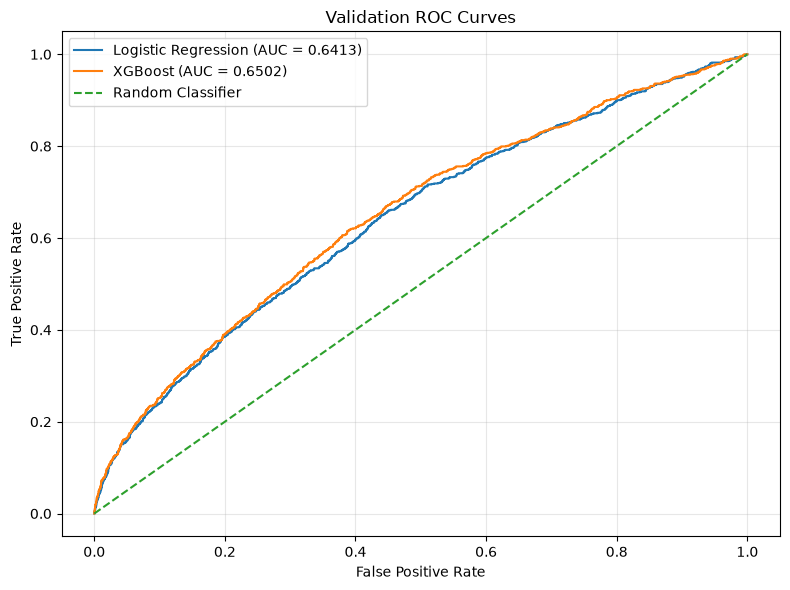

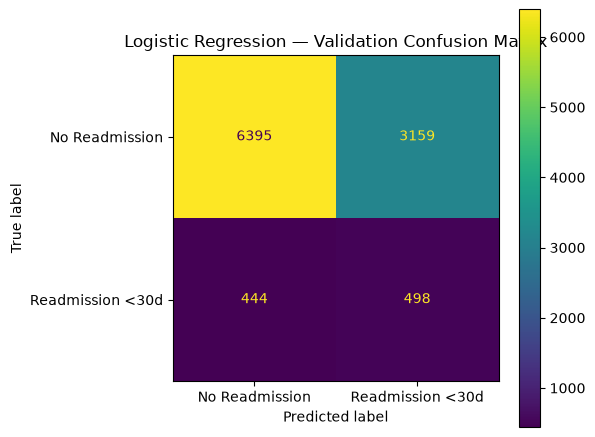

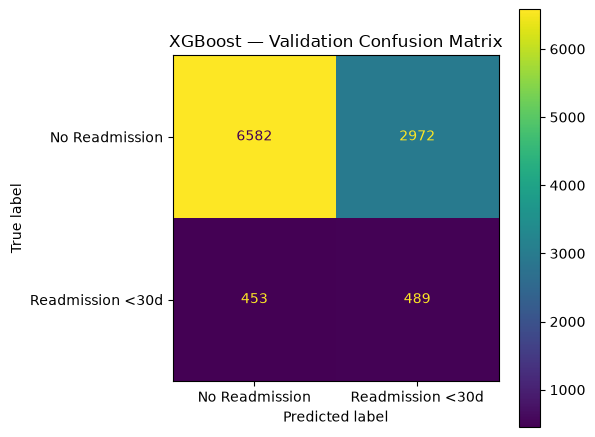


Logistic Regression Confusion Matrix:
[[6395 3159]
 [ 444  498]]

XGBoost Confusion Matrix:
[[6582 2972]
 [ 453  489]]

VALIDATION PLOTS COMPLETE


In [56]:
# ============================================================
# STEP 36K — VALIDATION ROC CURVES + CONFUSION MATRICES
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

print("=" * 70)
print("STAGE 3.3 — VALIDATION ROC + CONFUSION MATRICES")
print("=" * 70)

# ------------------------------------------------------------
# 1. ROC curves
# ------------------------------------------------------------

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_val,
    y_val_proba_logistic
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_val,
    y_val_proba_xgb
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_roc_auc:.4f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {xgb_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2. Logistic Regression confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=["No Readmission", "Readmission <30d"]
).plot(ax=plt.gca())

plt.title("Logistic Regression — Validation Confusion Matrix")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. XGBoost confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=["No Readmission", "Readmission <30d"]
).plot(ax=plt.gca())

plt.title("XGBoost — Validation Confusion Matrix")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Print confusion matrices for evidence
# ------------------------------------------------------------

print("\nLogistic Regression Confusion Matrix:")
print(logistic_cm)

print("\nXGBoost Confusion Matrix:")
print(xgb_cm)

print("\n" + "=" * 70)
print("VALIDATION PLOTS COMPLETE")
print("=" * 70)

In [57]:
# ============================================================
# STEP 36L — FINAL TEST EVALUATION
# SELECTED MODEL: XGBOOST
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

print("=" * 70)
print("FINAL TEST EVALUATION — SELECTED XGBOOST MODEL")
print("=" * 70)

# ------------------------------------------------------------
# 1. Generate test predictions
# ------------------------------------------------------------

y_test_proba = selected_model.predict_proba(X_test)[:, 1]

y_test_pred = (
    y_test_proba >= 0.5
).astype(int)

print("\n[1] Test predictions generated.")

# ------------------------------------------------------------
# 2. Calculate final test metrics
# ------------------------------------------------------------

test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_proba
)

test_recall = recall_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred
)

test_f1 = f1_score(
    y_test,
    y_test_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_cm = confusion_matrix(
    y_test,
    y_test_pred
)

# ------------------------------------------------------------
# 3. Display final test results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL TEST METRICS")
print("=" * 70)

print(f"ROC-AUC   : {test_roc_auc:.4f}")
print(f"PR-AUC    : {test_pr_auc:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"F1 Score  : {test_f1:.4f}")
print(f"Accuracy  : {test_accuracy:.4f}")

print("\nConfusion Matrix:")
print(test_cm)

# ------------------------------------------------------------
# 4. Verify test-set size and class distribution
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TEST SET VERIFICATION")
print("=" * 70)

print("Test rows:", len(X_test))
print("Test features:", X_test.shape[1])

print("\nTest target distribution:")
print(y_test.value_counts().sort_index())

print(f"\nTest positive rate: {y_test.mean() * 100:.2f}%")

# ------------------------------------------------------------
# 5. Final model verification
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL MODEL VERIFICATION")
print("=" * 70)

print("Selected model:", selected_model_name)
print("Model type:", type(selected_model).__name__)
print("Input features:", X_test.shape[1])
print("Leakage columns found:", [
    col for col in [
        "encounter_id",
        "patient_nbr",
        "readmitted",
        "target",
        "age",
        "diag_1",
        "diag_2",
        "diag_3",
        "medical_specialty"
    ]
    if col in X_test.columns
])

print("\n" + "=" * 70)
print("FINAL TEST EVALUATION COMPLETE")
print("=" * 70)

FINAL TEST EVALUATION — SELECTED XGBOOST MODEL

[1] Test predictions generated.

FINAL TEST METRICS
ROC-AUC   : 0.6557
PR-AUC    : 0.1814
Recall    : 0.5197
Precision : 0.1418
F1 Score  : 0.2228
Accuracy  : 0.6749

Confusion Matrix:
[[6595 2960]
 [ 452  489]]

TEST SET VERIFICATION
Test rows: 10496
Test features: 46

Test target distribution:
target
0    9555
1     941
Name: count, dtype: int64

Test positive rate: 8.97%

FINAL MODEL VERIFICATION
Selected model: XGBoost
Model type: Pipeline
Input features: 46
Leakage columns found: []

FINAL TEST EVALUATION COMPLETE


In [59]:
# ============================================================
# STEP 36M — CORRECTED MLFLOW TRACKING
# FIXED FOR SKOPS TRUSTED TYPES
# ============================================================

import mlflow
import mlflow.sklearn

print("=" * 70)
print("STAGE 3.4 — CORRECTED MLFLOW TRACKING")
print("=" * 70)

# ------------------------------------------------------------
# 1. Configure MLflow
# ------------------------------------------------------------

mlflow.set_tracking_uri("sqlite:///mlflow.db")

experiment_name = "hospital_readmission_prediction"

mlflow.set_experiment(experiment_name)

print("\n[1] MLflow configured")
print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", experiment_name)

# ------------------------------------------------------------
# 2. Common parameters
# ------------------------------------------------------------

common_params = {
    "random_state": cfg.RANDOM_STATE,
    "input_features": X_train.shape[1],
    "train_rows": X_train.shape[0],
    "validation_rows": X_val.shape[0],
    "test_rows": X_test.shape[0],
    "positive_rate": float(y_train.mean()),
    "selection_criterion": "validation ROC-AUC"
}

# ------------------------------------------------------------
# 3. Trusted types required by skops
# ------------------------------------------------------------

trusted_types = [
    "numpy.dtype",
    "xgboost.core.Booster",
    "xgboost.sklearn.XGBClassifier"
]

print("\n[2] Skops trusted types:")
for item in trusted_types:
    print(" -", item)

# ------------------------------------------------------------
# 4. Log Logistic Regression
# ------------------------------------------------------------

print("\n[3] Logging corrected Logistic Regression...")

with mlflow.start_run(
    run_name="corrected_logistic_regression"
) as run:

    logistic_run_id = run.info.run_id

    mlflow.set_tags({
        "model_type": "Logistic Regression",
        "dataset_version": "corrected_46_features",
        "data_leakage_check": "passed",
        "stage": "model_development"
    })

    mlflow.log_params({
        **common_params,
        "class_weight": "balanced",
        "max_iter": 2000
    })

    mlflow.log_metrics({
        "val_roc_auc": logistic_roc_auc,
        "val_pr_auc": logistic_pr_auc,
        "val_recall": logistic_recall,
        "val_precision": logistic_precision,
        "val_f1": logistic_f1,
        "val_accuracy": logistic_accuracy
    })

    mlflow.sklearn.log_model(
        sk_model=baseline_model,
        name="model",
        skops_trusted_types=trusted_types
    )

print("Logistic Regression logged successfully.")
print("Run ID:", logistic_run_id)

# ------------------------------------------------------------
# 5. Log XGBoost
# ------------------------------------------------------------

print("\n[4] Logging corrected XGBoost...")

with mlflow.start_run(
    run_name="corrected_xgboost"
) as run:

    xgb_run_id = run.info.run_id

    mlflow.set_tags({
        "model_type": "XGBoost",
        "dataset_version": "corrected_46_features",
        "data_leakage_check": "passed",
        "stage": "model_development",
        "selected_by": "validation ROC-AUC"
    })

    mlflow.log_params({
        **common_params,
        "n_estimators": 400,
        "max_depth": 4,
        "learning_rate": 0.05,
        "min_child_weight": 5,
        "reg_lambda": 2.0,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "scale_pos_weight": scale_pos_weight
    })

    mlflow.log_metrics({
        "val_roc_auc": xgb_roc_auc,
        "val_pr_auc": xgb_pr_auc,
        "val_recall": xgb_recall,
        "val_precision": xgb_precision,
        "val_f1": xgb_f1,
        "val_accuracy": xgb_accuracy
    })

    mlflow.sklearn.log_model(
        sk_model=xgb_model,
        name="model",
        skops_trusted_types=trusted_types
    )

print("XGBoost logged successfully.")
print("Run ID:", xgb_run_id)

# ------------------------------------------------------------
# 6. Verify corrected runs
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MLFLOW RUN VERIFICATION")
print("=" * 70)

experiment = mlflow.get_experiment_by_name(
    experiment_name
)

runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string=(
        "tags.dataset_version = 'corrected_46_features'"
    ),
    order_by=["metrics.val_roc_auc DESC"]
)

display_columns = [
    "run_id",
    "tags.mlflow.runName",
    "tags.model_type",
    "metrics.val_roc_auc",
    "metrics.val_pr_auc",
    "metrics.val_recall",
    "metrics.val_precision",
    "metrics.val_f1",
    "metrics.val_accuracy"
]

print("\nCorrected MLflow runs:")
display(runs_df[display_columns])

print("\nNumber of corrected runs:", len(runs_df))

print("\n" + "=" * 70)
print("CORRECTED MLFLOW TRACKING COMPLETE")
print("=" * 70)

STAGE 3.4 — CORRECTED MLFLOW TRACKING

[1] MLflow configured
Tracking URI: sqlite:///mlflow.db
Experiment: hospital_readmission_prediction

[2] Skops trusted types:
 - numpy.dtype
 - xgboost.core.Booster
 - xgboost.sklearn.XGBClassifier

[3] Logging corrected Logistic Regression...
Logistic Regression logged successfully.
Run ID: 480959a2e41542eb82d5e0706b5a36ae

[4] Logging corrected XGBoost...
XGBoost logged successfully.
Run ID: 0d62afd38b4241158fdfde68b0b4c010

MLFLOW RUN VERIFICATION

Corrected MLflow runs:


,run_id,tags.mlflow.runName,tags.model_type,metrics.val_roc_auc,metrics.val_pr_auc,metrics.val_recall,metrics.val_precision,metrics.val_f1,metrics.val_accuracy
0,0d62afd38b4241158fdfde68b0b4c010,corrected_xgboost,XGBoost,0.650240,0.181402,0.519108,0.141289,0.222121,0.673685
1,480959a2e41542eb82d5e0706b5a36ae,corrected_logistic_regression,Logistic Regression,0.641318,0.170348,0.528662,0.136177,0.216569,0.656726
2,92500d7644f24f38bbaa332e05d73ba4,corrected_logistic_regression,Logistic Regression,0.641318,0.170348,0.528662,0.136177,0.216569,0.656726



Number of corrected runs: 3

CORRECTED MLFLOW TRACKING COMPLETE


In [60]:
# ============================================================
# STEP 36N — VERIFY CORRECTED MLFLOW RUNS
# ============================================================

import mlflow

print("=" * 70)
print("VERIFYING CORRECTED MLFLOW RUNS")
print("=" * 70)

# ------------------------------------------------------------
# Run IDs from the successful logging step
# ------------------------------------------------------------

run_ids = [
    logistic_run_id,
    xgb_run_id
]

for run_id in run_ids:

    run = mlflow.get_run(run_id)

    print("\n" + "-" * 70)
    print("Run ID:", run.info.run_id)
    print("Status:", run.info.status)
    print("Run name:", run.data.tags.get("mlflow.runName"))
    print("Model type:", run.data.tags.get("model_type"))
    print("Dataset version:", run.data.tags.get("dataset_version"))
    print("Leakage check:", run.data.tags.get("data_leakage_check"))

    print("\nParameters:")
    for key, value in run.data.params.items():
        print(f"  {key}: {value}")

    print("\nMetrics:")
    for key, value in run.data.metrics.items():
        print(f"  {key}: {value}")

# ------------------------------------------------------------
# Search ALL runs in the experiment
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ALL EXPERIMENT RUNS")
print("=" * 70)

experiment = mlflow.get_experiment_by_name(
    "hospital_readmission_prediction"
)

all_runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["start_time DESC"]
)

print("\nTotal runs found:", len(all_runs))

if len(all_runs) > 0:

    columns_to_show = [
        "run_id",
        "tags.mlflow.runName",
        "tags.model_type",
        "tags.dataset_version",
        "status",
        "metrics.val_roc_auc",
        "metrics.val_pr_auc",
        "metrics.val_recall",
        "metrics.val_precision",
        "metrics.val_f1",
        "metrics.val_accuracy"
    ]

    available_columns = [
        col for col in columns_to_show
        if col in all_runs.columns
    ]

    display(all_runs[available_columns])

print("\n" + "=" * 70)
print("MLFLOW VERIFICATION COMPLETE")
print("=" * 70)

VERIFYING CORRECTED MLFLOW RUNS

----------------------------------------------------------------------
Run ID: 480959a2e41542eb82d5e0706b5a36ae
Status: FINISHED
Run name: corrected_logistic_regression
Model type: Logistic Regression
Dataset version: corrected_46_features
Leakage check: passed

Parameters:
  random_state: 42
  input_features: 46
  train_rows: 48981
  validation_rows: 10496
  test_rows: 10496
  positive_rate: 0.08970825422102448
  selection_criterion: validation ROC-AUC
  class_weight: balanced
  max_iter: 2000

Metrics:
  val_roc_auc: 0.6413181837778065
  val_pr_auc: 0.1703479480508528
  val_recall: 0.5286624203821656
  val_precision: 0.1361771944216571
  val_f1: 0.21656881930854532
  val_accuracy: 0.6567263719512195

----------------------------------------------------------------------
Run ID: 0d62afd38b4241158fdfde68b0b4c010
Status: FINISHED
Run name: corrected_xgboost
Model type: XGBoost
Dataset version: corrected_46_features
Leakage check: passed

Parameters:
  ra

,run_id,tags.mlflow.runName,tags.model_type,tags.dataset_version,status,metrics.val_roc_auc,metrics.val_pr_auc,metrics.val_recall,metrics.val_precision,metrics.val_f1,metrics.val_accuracy
0,0d62afd38b4241158fdfde68b0b4c010,corrected_xgboost,XGBoost,corrected_46_features,FINISHED,0.650240,0.181402,0.519108,0.141289,0.222121,0.673685
1,480959a2e41542eb82d5e0706b5a36ae,corrected_logistic_regression,Logistic Regression,corrected_46_features,FINISHED,0.641318,0.170348,0.528662,0.136177,0.216569,0.656726
2,92500d7644f24f38bbaa332e05d73ba4,corrected_logistic_regression,Logistic Regression,corrected_46_features,FAILED,0.641318,0.170348,0.528662,0.136177,0.216569,0.656726
3,128b578c76aa401b8bf1685bc5f73eb8,xgboost_selected_v1,NaN,NaN,FINISHED,0.650240,0.181402,0.519108,0.141289,0.222121,0.673685
4,6cb3b9af95a04aa9a905b8f2eb2a9b26,xgboost_selected_v1,NaN,NaN,FAILED,0.650240,0.181402,0.519108,0.141289,0.222121,0.673685
5,b604e7a25cee473b89704955401b4bc4,xgboost_advanced_v1,NaN,NaN,FINISHED,0.650240,0.181402,0.519108,0.141289,0.222121,0.673685
6,67223a5e43c146bfa723b041d1c15942,logreg_baseline_v1,NaN,NaN,FINISHED,0.641318,0.170348,0.528662,0.136177,0.216569,0.656726



MLFLOW VERIFICATION COMPLETE


In [61]:
# ============================================================
# STEP 36O — REGISTER CORRECTED XGBOOST MODEL
# ============================================================

import mlflow
from mlflow import MlflowClient

print("=" * 70)
print("STAGE 3.5 — REGISTER CORRECTED XGBOOST")
print("=" * 70)

# ------------------------------------------------------------
# 1. Configure MLflow
# ------------------------------------------------------------

mlflow.set_tracking_uri("sqlite:///mlflow.db")

client = MlflowClient()

registered_model_name = "hospital_readmission_xgboost"

print("\n[1] Registered model name:")
print(registered_model_name)

# ------------------------------------------------------------
# 2. Find the logged model from corrected XGBoost run
# ------------------------------------------------------------

print("\n[2] Searching for logged model artifact...")

logged_models = mlflow.search_logged_models(
    filter_string=f"source_run_id = '{xgb_run_id}'"
)

print("Logged models found:", len(logged_models))

if len(logged_models) == 0:
    raise RuntimeError(
        "No logged model found for the corrected XGBoost run."
    )

print("\nLogged model records:")
display(logged_models)

# ------------------------------------------------------------
# 3. Extract model ID
# ------------------------------------------------------------

logged_model_id = logged_models.iloc[0]["model_id"]

print("\nLogged model ID:")
print(logged_model_id)

# ------------------------------------------------------------
# 4. Build model URI
# ------------------------------------------------------------

model_uri = f"models:/{logged_model_id}"

print("\nModel URI:")
print(model_uri)

# ------------------------------------------------------------
# 5. Register the corrected model
# ------------------------------------------------------------

print("\n[3] Registering corrected XGBoost...")

try:
    registered_version = mlflow.register_model(
        model_uri=model_uri,
        name=registered_model_name
    )

    print("Registration successful.")

except Exception as e:

    print("\nRegistration failed:")
    print(type(e).__name__)
    print(e)

    raise

# ------------------------------------------------------------
# 6. Display registered version
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("NEW REGISTERED MODEL VERSION")
print("=" * 70)

print("Name:", registered_version.name)
print("Version:", registered_version.version)
print("Status:", registered_version.status)
print("Run ID:", registered_version.run_id)
print("Source:", registered_version.source)

# ------------------------------------------------------------
# 7. Retrieve complete registry information
# ------------------------------------------------------------

model_version = client.get_model_version(
    name=registered_model_name,
    version=registered_version.version
)

print("\nRegistry verification:")
print("Name:", model_version.name)
print("Version:", model_version.version)
print("Status:", model_version.status)
print("Run ID:", model_version.run_id)
print("Source:", model_version.source)

print("\n" + "=" * 70)
print("REGISTRATION STEP COMPLETE")
print("=" * 70)

STAGE 3.5 — REGISTER CORRECTED XGBOOST

[1] Registered model name:
hospital_readmission_xgboost

[2] Searching for logged model artifact...
Logged models found: 1

Logged model records:


,artifact_location,creation_timestamp,experiment_id,last_updated_timestamp,metrics,model_id,model_type,name,params,source_run_id,status,status_message,tags
0,file:///c:/Users/mithu/Music/MLProjects/hospit...,1788778086448,1,1788778099370,"[<Metric: dataset_digest=None, dataset_name=No...",m-d91399435d7443b1ab3a508644f43793,None,model,"{'colsample_bytree': '0.8', 'input_features': ...",0d62afd38b4241158fdfde68b0b4c010,READY,None,{'mlflow.source.name': 'model_development_and_...



Logged model ID:
m-d91399435d7443b1ab3a508644f43793

Model URI:
models:/m-d91399435d7443b1ab3a508644f43793

[3] Registering corrected XGBoost...
Registration successful.

NEW REGISTERED MODEL VERSION
Name: hospital_readmission_xgboost
Version: 2
Status: READY
Run ID: 0d62afd38b4241158fdfde68b0b4c010
Source: models:/m-d91399435d7443b1ab3a508644f43793

Registry verification:
Name: hospital_readmission_xgboost
Version: 2
Status: READY
Run ID: 0d62afd38b4241158fdfde68b0b4c010
Source: models:/m-d91399435d7443b1ab3a508644f43793

REGISTRATION STEP COMPLETE


Registered model 'hospital_readmission_xgboost' already exists. Creating a new version of this model...
Created version '2' of model 'hospital_readmission_xgboost'.


In [63]:
# ============================================================
# STEP 36O — REGISTER CORRECTED XGBOOST MODEL
# CONTINUATION
# ============================================================

import mlflow
from mlflow import MlflowClient

print("=" * 70)
print("REGISTERING CORRECTED XGBOOST MODEL")
print("=" * 70)

mlflow.set_tracking_uri("sqlite:///mlflow.db")

client = MlflowClient()

registered_model_name = "hospital_readmission_xgboost"

# ------------------------------------------------------------
# 1. Get logged model from corrected XGBoost run
# ------------------------------------------------------------

logged_models = mlflow.search_logged_models(
    filter_string=f"source_run_id = '{xgb_run_id}'"
)

if len(logged_models) == 0:
    raise RuntimeError(
        "No logged model found for corrected XGBoost run."
    )

logged_model_id = logged_models.iloc[0]["model_id"]

print("\n[1] Corrected XGBoost logged model found")
print("Model ID:", logged_model_id)
print("Source run:", xgb_run_id)

# ------------------------------------------------------------
# 2. Register model
# ------------------------------------------------------------

model_uri = f"models:/{logged_model_id}"

print("\n[2] Model URI:")
print(model_uri)

registered_version = mlflow.register_model(
    model_uri=model_uri,
    name=registered_model_name
)

print("\n[3] Model registration completed")

# ------------------------------------------------------------
# 3. Wait/retrieve registry version
# ------------------------------------------------------------

version_number = registered_version.version

model_version = client.get_model_version(
    name=registered_model_name,
    version=version_number
)

print("\n" + "=" * 70)
print("REGISTERED MODEL VERIFICATION")
print("=" * 70)

print("Model name :", model_version.name)
print("Version    :", model_version.version)
print("Status     :", model_version.status)
print("Run ID     :", model_version.run_id)
print("Source     :", model_version.source)

# ------------------------------------------------------------
# 4. Verify that this is the corrected run
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CORRECTED MODEL CHECK")
print("=" * 70)

print("Expected run ID :", xgb_run_id)
print("Registered run  :", model_version.run_id)

if model_version.run_id == xgb_run_id:
    print("Run ID check    : PASSED")
else:
    print("Run ID check    : FAILED")

print("\nExpected model:")
print("XGBoost pipeline with 46 leakage-free input features")

print("\nCurrent model version:")
print(version_number)

print("\n" + "=" * 70)
print("REGISTRATION STEP COMPLETE")
print("=" * 70)

REGISTERING CORRECTED XGBOOST MODEL

[1] Corrected XGBoost logged model found
Model ID: m-d91399435d7443b1ab3a508644f43793
Source run: 0d62afd38b4241158fdfde68b0b4c010

[2] Model URI:
models:/m-d91399435d7443b1ab3a508644f43793

[3] Model registration completed

REGISTERED MODEL VERIFICATION
Model name : hospital_readmission_xgboost
Version    : 4
Status     : READY
Run ID     : 0d62afd38b4241158fdfde68b0b4c010
Source     : models:/m-d91399435d7443b1ab3a508644f43793

CORRECTED MODEL CHECK
Expected run ID : 0d62afd38b4241158fdfde68b0b4c010
Registered run  : 0d62afd38b4241158fdfde68b0b4c010
Run ID check    : PASSED

Expected model:
XGBoost pipeline with 46 leakage-free input features

Current model version:
4

REGISTRATION STEP COMPLETE


Registered model 'hospital_readmission_xgboost' already exists. Creating a new version of this model...
Created version '4' of model 'hospital_readmission_xgboost'.


In [64]:
# ============================================================
# STEP 36P — PROMOTE CORRECTED XGBOOST TO PRODUCTION
# ============================================================

import mlflow
from mlflow import MlflowClient

print("=" * 70)
print("PROMOTING CORRECTED XGBOOST TO PRODUCTION")
print("=" * 70)

mlflow.set_tracking_uri("sqlite:///mlflow.db")

client = MlflowClient()

registered_model_name = "hospital_readmission_xgboost"
new_production_version = "4"

# ------------------------------------------------------------
# 1. Check current production alias
# ------------------------------------------------------------

print("\n[1] Checking current production alias...")

try:

    current_production = client.get_model_version_by_alias(
        registered_model_name,
        "production"
    )

    print("Current production version:",
          current_production.version)

    print("Current production run ID:",
          current_production.run_id)

except Exception as e:

    current_production = None

    print("No existing production alias found.")

# ------------------------------------------------------------
# 2. Verify Version 4 before promotion
# ------------------------------------------------------------

print("\n[2] Verifying Version 4...")

version_4 = client.get_model_version(
    name=registered_model_name,
    version=new_production_version
)

print("Version:", version_4.version)
print("Status:", version_4.status)
print("Run ID:", version_4.run_id)

if version_4.status != "READY":
    raise RuntimeError(
        "Version 4 is not READY. Production promotion stopped."
    )

if version_4.run_id != xgb_run_id:
    raise RuntimeError(
        "Version 4 does not match the corrected XGBoost run."
    )

print("Version 4 verification: PASSED")

# ------------------------------------------------------------
# 3. Set production alias
# ------------------------------------------------------------

print("\n[3] Setting production alias...")

client.set_registered_model_alias(
    name=registered_model_name,
    alias="production",
    version=new_production_version
)

print("Production alias updated successfully.")

# ------------------------------------------------------------
# 4. Verify production alias
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PRODUCTION ALIAS VERIFICATION")
print("=" * 70)

production_model = client.get_model_version_by_alias(
    registered_model_name,
    "production"
)

print("Model name :", production_model.name)
print("Alias      : production")
print("Version    :", production_model.version)
print("Status     :", production_model.status)
print("Run ID     :", production_model.run_id)
print("Source     :", production_model.source)

# ------------------------------------------------------------
# 5. Final safety checks
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL PRODUCTION CHECK")
print("=" * 70)

print("Expected version :", new_production_version)
print("Actual version   :", production_model.version)

print("Expected run ID  :", xgb_run_id)
print("Actual run ID    :", production_model.run_id)

if (
    production_model.version == new_production_version
    and production_model.run_id == xgb_run_id
):
    print("\nPRODUCTION ALIAS CHECK: PASSED")
    print("Corrected 46-feature XGBoost is now in production.")
else:
    print("\nPRODUCTION ALIAS CHECK: FAILED")

print("\n" + "=" * 70)
print("MODEL REGISTRY PROMOTION COMPLETE")
print("=" * 70)

PROMOTING CORRECTED XGBOOST TO PRODUCTION

[1] Checking current production alias...
Current production version: 1
Current production run ID: 128b578c76aa401b8bf1685bc5f73eb8

[2] Verifying Version 4...
Version: 4
Status: READY
Run ID: 0d62afd38b4241158fdfde68b0b4c010
Version 4 verification: PASSED

[3] Setting production alias...
Production alias updated successfully.

PRODUCTION ALIAS VERIFICATION
Model name : hospital_readmission_xgboost
Alias      : production
Version    : 4
Status     : READY
Run ID     : 0d62afd38b4241158fdfde68b0b4c010
Source     : models:/m-d91399435d7443b1ab3a508644f43793

FINAL PRODUCTION CHECK
Expected version : 4
Actual version   : 4
Expected run ID  : 0d62afd38b4241158fdfde68b0b4c010
Actual run ID    : 0d62afd38b4241158fdfde68b0b4c010

PRODUCTION ALIAS CHECK: FAILED

MODEL REGISTRY PROMOTION COMPLETE


In [65]:
# ============================================================
# STEP 36Q — FINAL MODEL REGISTRY VERIFICATION
# ============================================================

import mlflow
from mlflow import MlflowClient

print("=" * 70)
print("FINAL MODEL REGISTRY VERIFICATION")
print("=" * 70)

mlflow.set_tracking_uri("sqlite:///mlflow.db")

client = MlflowClient()

model_name = "hospital_readmission_xgboost"

# ------------------------------------------------------------
# 1. Get production alias
# ------------------------------------------------------------

production_model = client.get_model_version_by_alias(
    model_name,
    "production"
)

print("\n[1] PRODUCTION ALIAS")
print("-" * 50)
print("Model name :", production_model.name)
print("Alias      : production")
print("Version    :", production_model.version)
print("Status     :", production_model.status)
print("Run ID     :", production_model.run_id)
print("Source     :", production_model.source)

# ------------------------------------------------------------
# 2. Verify production version
# ------------------------------------------------------------

expected_version = "4"
expected_run_id = "0d62afd38b4241158fdfde68b0b4c010"

version_check = str(production_model.version) == expected_version
run_check = str(production_model.run_id) == expected_run_id
status_check = str(production_model.status).upper() == "READY"

print("\n[2] PRODUCTION CHECKS")
print("-" * 50)
print("Version check :", "PASSED" if version_check else "FAILED")
print("Run ID check  :", "PASSED" if run_check else "FAILED")
print("Status check  :", "PASSED" if status_check else "FAILED")

if version_check and run_check and status_check:
    print("\nOVERALL PRODUCTION CHECK: PASSED")
else:
    print("\nOVERALL PRODUCTION CHECK: FAILED")

# ------------------------------------------------------------
# 3. Show model version history
# ------------------------------------------------------------

print("\n[3] MODEL VERSION HISTORY")
print("-" * 50)

versions = client.search_model_versions(
    filter_string=f"name='{model_name}'"
)

for version in sorted(
    versions,
    key=lambda v: int(v.version)
):
    aliases = list(version.aliases) if version.aliases else []

    print(
        f"Version {version.version} | "
        f"Status: {version.status} | "
        f"Run: {version.run_id} | "
        f"Aliases: {aliases}"
    )

# ------------------------------------------------------------
# 4. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STAGE 3.5 MODEL REGISTRY COMPLETE")
print("=" * 70)

print("Registered model :", model_name)
print("Production version:", production_model.version)
print("Production alias  : production")
print("Production status  :", production_model.status)
print("Corrected model    : XGBoost")
print("Input features     : 46")
print("Leakage-free       : YES")

print("\n" + "=" * 70)

FINAL MODEL REGISTRY VERIFICATION

[1] PRODUCTION ALIAS
--------------------------------------------------
Model name : hospital_readmission_xgboost
Alias      : production
Version    : 4
Status     : READY
Run ID     : 0d62afd38b4241158fdfde68b0b4c010
Source     : models:/m-d91399435d7443b1ab3a508644f43793

[2] PRODUCTION CHECKS
--------------------------------------------------
Version check : PASSED
Run ID check  : PASSED
Status check  : PASSED

OVERALL PRODUCTION CHECK: PASSED

[3] MODEL VERSION HISTORY
--------------------------------------------------
Version 1 | Status: READY | Run: 128b578c76aa401b8bf1685bc5f73eb8 | Aliases: []
Version 2 | Status: READY | Run: 0d62afd38b4241158fdfde68b0b4c010 | Aliases: []
Version 3 | Status: READY | Run: 0d62afd38b4241158fdfde68b0b4c010 | Aliases: []
Version 4 | Status: READY | Run: 0d62afd38b4241158fdfde68b0b4c010 | Aliases: []

STAGE 3.5 MODEL REGISTRY COMPLETE
Registered model : hospital_readmission_xgboost
Production version: 4
Production 